In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
"""
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()


In [2]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):

    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()


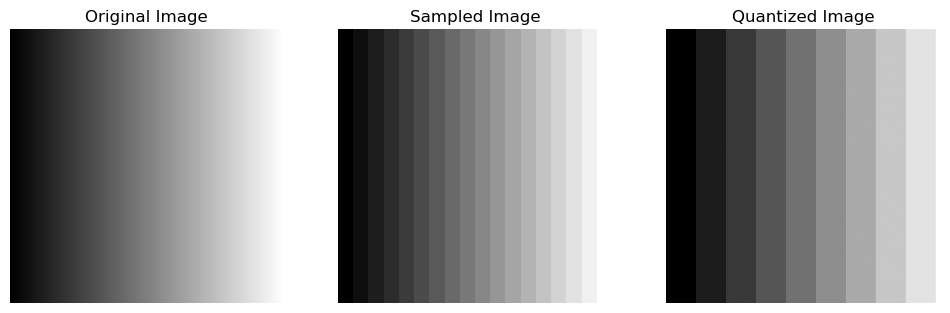

In [3]:
image_path='../images/lena_gray_256.tif'
sampling_factor=14
quantization_levels=9
# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


In [4]:
from PIL import Image
img1=Image.open('../images/lena_gray_256.tif')
img2=Image.open ('../images/cameraman.tif')

resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr
resultImage=Image.fromarray(addition)
resultImage.show()


In [5]:
img3=Image.open('../images/A.png')
img3.show()
img4=Image.open('../images/B.png')
img4.show()
resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)
im3arr=np.asarray(img3)
im4arr=np.asarray(img4)
union=im4arr|im3arr
resultImage2=Image.fromarray(union)
resultImage2.show() 


FileNotFoundError: [Errno 2] No such file or directory: '../images/A.png'

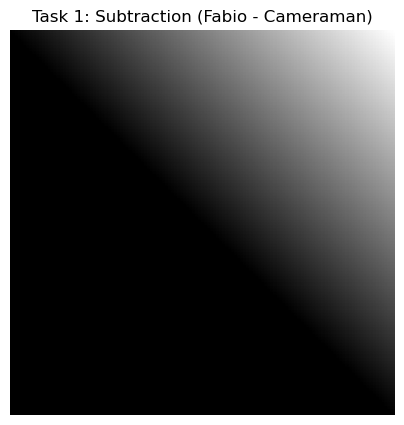

In [6]:
# cv2.subtract prevents negative underflow
subtraction = cv2.subtract(im1arr, im2arr)

plt.figure(figsize=(5, 5))
plt.imshow(subtraction, cmap='gray')
plt.title("Task 1: Subtraction (Fabio - Cameraman)")
plt.axis('off')
plt.show()

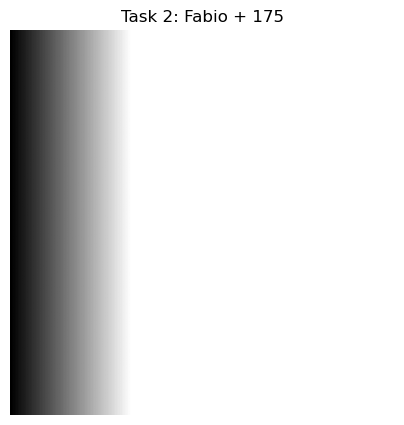

In [7]:
# cv2.add prevents overflow past 255
added_constant = cv2.add(im1arr, 175)

plt.figure(figsize=(5, 5))
plt.imshow(added_constant, cmap='gray')
plt.title("Task 2: Fabio + 175")
plt.axis('off')
plt.show()

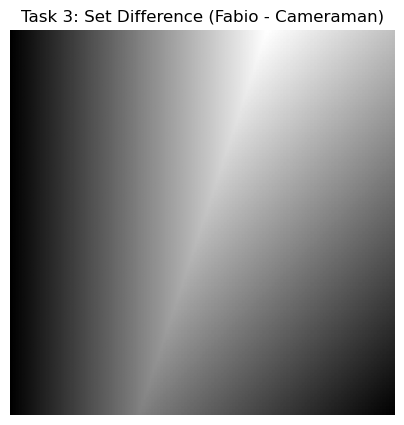

In [8]:
# Set Difference: A ∖ B = min(A, 255 - B)
complement_im2 = 255 - im2arr
set_difference = np.minimum(im1arr, complement_im2)

plt.figure(figsize=(5, 5))
plt.imshow(set_difference, cmap='gray')
plt.title("Task 3: Set Difference (Fabio - Cameraman)")
plt.axis('off')
plt.show()

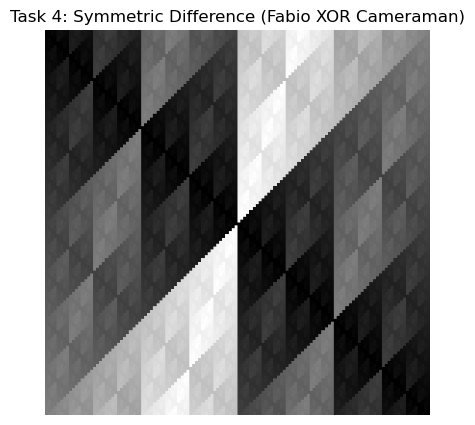

In [9]:
# Symmetric Difference using bitwise XOR (A ^ B)
symmetric_diff = im1arr ^ im2arr

plt.figure(figsize=(5, 5))
plt.imshow(symmetric_diff, cmap='gray')
plt.title("Task 4: Symmetric Difference (Fabio XOR Cameraman)")
plt.axis('off')
plt.show()

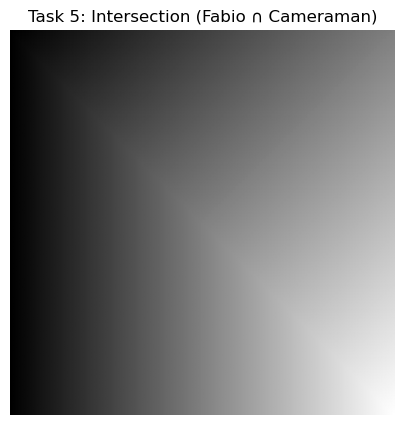

In [10]:
# Grayscale Intersection using pixel-wise minimum: min(A, B)
# (Alternatively, bitwise AND: im1arr & im2arr)
intersection = np.minimum(im1arr, im2arr)

plt.figure(figsize=(5, 5))
plt.imshow(intersection, cmap='gray')
plt.title("Task 5: Intersection (Fabio ∩ Cameraman)")
plt.axis('off')
plt.show()